In [1]:
import os
from dotenv import load_dotenv
from rich import print as rprint
from rich.markdown import Markdown

In [2]:
load_dotenv()

True

# Настройка Langfuse для логирования

Langfuse - это платформа для наблюдения за LLM приложениями, которая позволяет отслеживать выполнение, затраты и качество работы агентов.

In [17]:
from langfuse.langchain import CallbackHandler

# Инициализация Langfuse callback handler для локальной версии
langfuse_handler = CallbackHandler(
    public_key=os.getenv("LANGFUSE_PUBLIC_KEY", "pk-lf-e9868dba-8d8a-4f53-83f0-e3dc0bf07338"),
    # secret_key=os.getenv("LANGFUSE_SECRET_KEY", "sk-lf-922d95c1-02e9-4585-a270-c6c468a10a68"),
    host=os.getenv("LANGFUSE_HOST", "http://localhost:3000")
)

TypeError: LangchainCallbackHandler.__init__() got an unexpected keyword argument 'host'

# LangGraph 101

[LLMs](https://python.langchain.com/docs/concepts/chat_models/) make it possible to embed intelligence into a new class of applications. [LangGraph](https://langchain-ai.github.io/langgraph/) is a framework to help build applications with LLMs. Here, we will overview the basics of LangGraph, explain its benefits, show how to use it to build workflows / agents, and show how it works with [LangChain](https://www.langchain.com/) / [LangSmith](https://docs.smith.langchain.com/).

![ecosystem](./img/ecosystem.png)

## Chat models

[Chat models](https://python.langchain.com/docs/concepts/chat_models/) are the foundation of LLM applications. They are typically accessed through a chat interface that takes a list of [messages](https://python.langchain.com/docs/concepts/messages/) as input and returns a [message](https://python.langchain.com/docs/concepts/messages/) as output.

In [12]:

from openai import OpenAI
from langchain_openai import ChatOpenAI
import json

In [13]:
from openai import OpenAI
import json

# Initialize OpenAI client that points to the local LM Studio server
inference_server_url = "http://localhost:11434/v1" 


llm = ChatOpenAI(
    model="qwen3",
    base_url=inference_server_url,
    api_key="no-key"
)

## Running the model

`Runnable` interface provides [standardized](https://python.langchain.com/docs/concepts/runnables/) methods for using chat models, which include:
- `invoke()`: A single input is transformed into an output.
- `stream()`: Outputs are [streamed](https://python.langchain.com/docs/concepts/streaming/#stream-and-astream) as they are produced. 

In [15]:
result = llm.invoke("Что такое LLM агент?")

In [16]:
rprint(result)

AIMessage(
    content='<think>\nХорошо, пользователь спрашивает, что такое LLM агент. Надо объяснить понятие простым языком. 
Сначала вспомню, что LLM — это большие языковые модели, например, GPT, BERT и т.д. Агент же, в контексте ИИ, как я 
понимаю, это система, которая может действовать автономно, принимая решения и взаимодействуя с окружающей 
средой.\n\nНо как сочетаются LLM и агент? Возможно, речь идет о гибридных моделях, где LLM служат основой для 
принятия решений, а агенты управления реализуют эти решения в реальном времени. Нужно уточнить, что LLM агент — 
это, вероятно, система, которая использует мощные языковые модели для обработки информации и принятия решений, 
возможно, в сложных задачах, требующих понимания контекста, диалога или генерации текста.\n\nСтоит упомянуть 
ключевые компоненты: LLM как основа, инфраструктура для генерации и анализа данных, алгоритмы принятия решений, и, 
возможно, интерфейс пользователя. Примеры таких агентов — это виртуальные помощники, chatbots, системы управления, 
которые могут управлять роботами или автоматизировать процессы на основе данных.\n\nНадо также отметить, что LLM 
агенты могут адаптироваться к новым контекстам, учитывая обновления и взаимодействуя с пользователем в реальном 
времени. Важно подчеркнуть, что это новая область, и существуют различные подходы и разработки в этой области. 
Возможно, стоит упомянуть современные примеры, такие как GPT-4, но конкретной информации о том, как именно работают
LLM агенты, может быть недостаточно. Нужно дать общее описание, объяснить основные характеристики и примеры 
применения, чтобы пользователь понял, что такое LLM агент.\n</think>\n\nLLM агент (Large Language Model Agent) — 
это система, которая использует мощные **большие языковые модели (LLM)** (например, GPT, BERT, LLaMA и др.) в 
качестве ядра для принятия решений, взаимодействия с окружающей средой и выполнения задач. Он сочетает в себе 
возможности LLM в понимании естественного языка и генерации текста с функциями автономного агента, способного 
действовать, учиться и адаптироваться.\n\n---\n\n### 🔍 Основные характеристики LLM агента:\n1. **Использование LLM
как "мозг"**  \n   LLM агент полагается на предварительно обученные модели для анализа данных, генерации ответов, 
планирования действий и принятия решений.\n\n2. **Взаимодействие с окружением**  \n   Агент может взаимодействовать
с внешними системами (например, базами данных, API, роботами) и пользователем, используя LLM для интерпретации 
запросов и формирования ответов.\n\n3. **Гибкость и адаптивность**  \n   Агент может адаптироваться к новым 
контекстам, учитывая обновления и изменения в окружающей среде, а также улучшать свои действия на основе обратной 
связи.\n\n4. **Реальное время и автономность**  \n   В отличие от статических LLM, агент может действовать 
самостоятельно, принимая решения и реализуя их в реальном времени.\n\n---\n\n### 📌 Примеры применения:\n- 
**Виртуальные помощники**: Ассистенты, которые могут управлять задачами, планировать встречи, анализировать данные 
и отвечать на вопросы.\n- **Автоматические чат-боты**: Системы поддержки клиентов, которые понимают сложные запросы
и предлагают решения.\n- **Роботы и системы управления**: Агенты, которые управляют промышленным оборудованием, 
дронами или умными домами на основе данных сенсоров.\n- **Инструменты для разработки**: Платформы, которые помогают
программистам генерировать код, улучшать алгоритмы и т.д.\n\n---\n\n### 📚 Как работают LLM агенты?\n1. **Входные 
данные**  \n   Агент получает информацию от пользователей, устройств или систем (например, запросы в чате, данные с
датчиков).\n2. **Обработка данных**  \n   LLM анализирует входные данные, идентифицирует нужную информацию и 
формирует план действий.\n3. **Принятие решений**  \n   На основе анализа агент принимает решение, возможно, 
выполняя действия (например, сгенерировать текст, отправить запрос в API, обновить данные).\n4. **Взаимодействие с 
окружением**  \n   Агент взаимодейств

In [18]:
Markdown(result.content)

Но как сочетаются LLM и агент? Возможно, речь идет о гибридных моделях, где LLM служат основой для принятия        
решений, а агенты управления реализуют эти решения в реальном времени. Нужно уточнить, что LLM агент — это,        
вероятно, система, которая использует мощные языковые модели для обработки информации и принятия решений, возможно,
в сложных задачах, требующих понимания контекста, диалога или генерации текста.                                    

Стоит упомянуть ключевые компоненты: LLM как основа, инфраструктура для генерации и анализа данных, алгоритмы      
принятия решений, и, возможно, интерфейс пользователя. Примеры таких агентов — это виртуальные помощники, chatbots,
системы управления, которые могут управлять роботами или автоматизировать процессы на основе данных.               


Надо также отметить, что LLM агенты могут адаптироваться к новым контекстам, учитывая обновления и взаимодействуя с
пользователем в реальном времени. Важно подчеркнуть, что это новая область, и существуют различные подходы и       
разработки в этой области. Возможно, стоит упомянуть современные примеры, такие как GPT-4, но конкретной информации
о том, как именно работают LLM агенты, может быть недостаточно. Нужно дать общее описание, объяснить основные      
характеристики и примеры применения, чтобы пользователь понял, что такое LLM агент.                                

LLM агент (Large Language Model Agent) — это система, которая использует мощные большие языковые модели (LLM)      
(например, GPT, BERT, LLaMA и др.) в качестве ядра для принятия решений, взаимодействия с окружающей средой и      
выполнения задач. Он сочетает в себе возможности LLM в понимании естественного языка и генерации текста с функциями
автономного агента, способного действовать, учиться и адаптироваться.                                              

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                      🔍 Основные характеристики LLM агента:                                       

 1 Использование LLM как "мозг"                                                                                    
   LLM агент полагается на предварительно обученные модели для анализа данных, генерации ответов, планирования     
   действий и принятия решений.                                                                                    
 2 Взаимодействие с окружением                                                                                     
   Агент может взаимодействовать с внешними системами (например, базами данных, API, роботами) и пользователем,    
   используя LLM для интерпретации запросов и формирования ответов.                                                
 3 Гибкость и адаптивность                                                                                         
   Агент может адаптироваться к новым контекстам, учитывая обновления и изменения в окружающей среде, а также      
   улучшать свои действия на основе обратной связи.                                                                
 4 Реальное время и автономность                                                                                   
   В отличие от статических LLM, агент может действовать самостоятельно, принимая решения и реализуя их в реальном 
   времени.                                                                                                        

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                              📌 Примеры применения:                                               

 • Виртуальные помощники: Ассистенты, которые могут управлять задачами, планировать встречи, анализировать данные и
   отвечать на вопросы.                                                                                            
 • Автоматические чат-боты: Системы поддержки клие

## Tools

[Tools](https://python.langchain.com/docs/concepts/tools/) are utilities that can be called by a chat model. In LangChain, creating tools can be done using the `@tool` decorator, which transforms Python functions into callable tools. It will automatically infer the tool's name, description, and expected arguments from the function definition. You can also use [Model Context Protocol (MCP) servers](https://github.com/langchain-ai/langchain-mcp-adapters) as LangChain-compatible tools. 

In [19]:
from langchain.tools import tool

In [20]:
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write a draft of email."""
    return f"Черновик письма создан\n\nTo: {to}\n\nSubject: {subject}\n\nContent:\n{content}"

@tool
def send_email(to: str, subject: str, content: str) -> str:
    """Send an email."""
    # Placeholder response - in real app would send email
    return f"Письмо отправлено\n\nTo: {to}\n\nSubject: {subject}\n\nContent:\n{content}"

In [21]:
rprint(write_email)

StructuredTool(
    name='write_email',
    description='Write a draft of email.',
    args_schema=<class 'langchain_core.utils.pydantic.write_email'>,
    func=<function write_email at 0x7fb2c82ba3e0>
)

## Tool Calling

Tools can be [called](https://python.langchain.com/docs/concepts/tool_calling/) by LLMs. When a tool is bound to the model, the model can choose to call the tool by returning a structured output with tool arguments. We use the `bind_tools` method to augment an LLM with tools.

![tool-img](img/tool_call_detail.png)

Providers often have [parameters such as `tool_choice`](https://python.langchain.com/docs/how_to/tool_choice/) to enforce calling specific tools.
 
In addition, we can [set `parallel_tool_calls=False`](https://python.langchain.com/docs/how_to/tool_calling_parallel/) to ensure the model will only call one tool at a time.

In [22]:
# Connect tools to a chat model
tools = [write_email]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(
    tools, tool_choice="write_email", parallel_tool_calls=False
)

# The model will now be able to call tools
output = llm_with_tools.invoke(
    "Подготовь ответ для моего начальника (boss@company.ai) по поводу завтрашней встречи."
)
rprint(output)

AIMessage(
    content='<think>\nOkay, the user wants to prepare a response for their boss about tomorrow\'s meeting. Let me 
see. The tools available include a function to write an email. The function requires \'to\', \'subject\', and 
\'content\' parameters.\n\nFirst, the \'to\' address is clearly boss@company.ai as mentioned. The subject should be
concise, maybe "Preparation for Tomorrow\'s Meeting" to indicate the purpose. For the content, the user might need 
to include details like time, agenda, or any specific points they want to discuss. But since the user didn\'t 
provide specifics, I should prompt them to add more details. Alternatively, I can offer a draft placeholder. Wait, 
the function requires the content parameter, so maybe I should generate a sample content if the user hasn\'t 
provided it. But the user\'s query is just asking to prepare the answer, not the content yet. Hmm. Maybe I should 
call the function with the available info and let the user fill in the content. Or perhaps the user expects a 
draft. Let me check the function\'s description again. The function is for drafting an email, so I can create a 
sample content. For example, "I am preparing for tomorrow\'s meeting and will provide the necessary materials by 
noon. Please let me know if there are any additional points to discuss." That way, the email is structured with the
required parameters. I\'ll proceed to call the function with the to, subject, and a sample content.\n</think>\n\n',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 367,
            'prompt_tokens': 185,
            'total_tokens': 552,
            'completion_tokens_details': None,
            'prompt_tokens_details': None
        },
        'model_provider': 'openai',
        'model_name': 'qwen3',
        'system_fingerprint': 'fp_ollama',
        'id': 'chatcmpl-479',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--3945d52f-c199-4b6f-83e1-45d5ba884d92-0',
    tool_calls=[
        {
            'name': 'write_email',
            'args': {
                'content': "I am preparing for tomorrow's meeting and will provide the necessary materials by noon.
Please let me know if there are any additional points to discuss.",
                'subject': "Preparation for Tomorrow's Meeting",
                'to': 'boss@company.ai'
            },
            'id': 'call_nahs2rak',
            'type': 'tool_call'
        }
    ],
    usage_metadata={
        'input_tokens': 185,
        'output_tokens': 367,
        'total_tokens': 552,
        'input_token_details': {},
        'output_token_details': {}
    }
)

In [23]:
# Extract tool calls
rprint(output.tool_calls[0])

{
    'name': 'write_email',
    'args': {
        'content': "I am preparing for tomorrow's meeting and will provide the necessary materials by noon. Please 
let me know if there are any additional points to discuss.",
        'subject': "Preparation for Tomorrow's Meeting",
        'to': 'boss@company.ai'
    },
    'id': 'call_nahs2rak',
    'type': 'tool_call'
}

In [24]:
# Call the tool
args = output.tool_calls[0]["args"]
result = write_email.invoke(args)
rprint(result.replace('\\n', '\n'))

Черновик письма создан

To: boss@company.ai

Subject: Preparation for Tomorrow's Meeting

Content:
I am preparing for tomorrow's meeting and will provide the necessary materials by noon. Please let me know if there
are any additional points to discuss.

![basic_prompt](img/tool_call.png)

## Workflows
 
There are many patterns for building applications with LLMs. 

[We can embed LLM calls into pre-defined workflows](https://langchain-ai.github.io/langgraph/tutorials/workflows/), giving the system more agency to make decisions. 

As an example, we could add a router step to determine whether to write an email or not.

![workflow_example](img/workflow_example.png)

## Agents

We can further increase agency, allowing the LLM to dynamically direct its own tool usage. 

[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/) are typically implemented as tool calling in a loop, where the output of each tool call is used to inform the next action.

![agent_example](img/agent_example.png)

Agents are well suited to open-ended problems where it's difficult to predict the *exact* steps needed in advance.
 
Workflows are often appropriate when the control flow can easily be defined in advance. 

![workflow_v_agent](img/workflow_v_agent.png)

## What is LangGraph? 

[LangGraph](https://langchain-ai.github.io/langgraph/concepts/high_level/) provides low-level supporting infrastructure that sits underneath *any* workflow or agent. 

It does not abstract prompts or architecture, and provides a few benefits:

- **Control**: Make it easy to define and / or combine agents and workflows.
- **Persistence**: Provide a way to persist the state of a graph, which enables both memory and human-in-the-loop.
- **Testing, Debugging, and Deployment**: Provide an easy onramp for testing, debugging, and deploying applications.

### Control

LangGraph lets you define your application as a graph with:

1. *State*: What information do we need to track over the course of the application?
2. *Nodes*: How do we want to update this information over the course of the application?
3. *Edges*: How do we want to connect these nodes together?

We can use the [`StateGraph` class](https://langchain-ai.github.io/langgraph/concepts/low_level/#stategraph) to initialize a LangGraph graph with a [`State` object](https://langchain-ai.github.io/langgraph/concepts/low_level/#state).

`State` defines the schema for information we want to track over the course of the application. 

This can be any object with `getattr()` in python, such as a dictionary, dataclass, or Pydantic object: 

- TypeDict is fastest but doesn’t support defaults
- Dataclass is basically as fast, supports dot syntax `state.foo`, and has defaults. 
- Pydantic is slower (especially with custom validators) but gives type validation.

In [27]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph

from email_assistant.utils import show_graph

ModuleNotFoundError: No module named 'email_assistant.utils'

In [15]:
class StateSchema(TypedDict):
    request: str
    email: str

workflow = StateGraph(StateSchema)

Each node is simply a python function or typescript code. This gives us full control over the logic inside each node.

They receive the current state, and return a dictionary to update the state.

By default, [state keys are overwritten](https://langchain-ai.github.io/langgraph/how-tos/state-reducers/). 

However, you can [define custom update logic](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers). 

![nodes_edges](img/nodes_edges.png)

In [16]:
def write_email_node(state: StateSchema) -> StateSchema:
    # Imperative code that processes the request
    output = llm_with_tools.invoke(state["request"])
    args = output.tool_calls[0]["args"]
    email = write_email.invoke(args)
    return {"email": email}

Edges connect nodes together. 

We specify the control flow by adding edges and nodes to our state graph. 

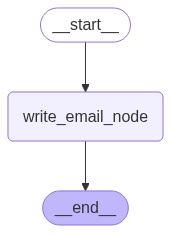

In [17]:
workflow = StateGraph(StateSchema)
workflow.add_node("write_email_node", write_email_node)
workflow.add_edge(START, "write_email_node")
workflow.add_edge("write_email_node", END)

app = workflow.compile()
show_graph(app)

In [18]:
response = app.invoke(
    {
        "request": "Подготовь ответ для моего начальника (boss@company.ai) по поводу завтрашней встречи."
    }
)
rprint(response)

{
    'request': 'Подготовь ответ для моего начальника (boss@company.ai) по поводу завтрашней встречи.',
    'email': 'Черновик письма создан\n\nTo: boss@company.ai\n\nSubject: Подтверждение встречи 
завтра\n\nContent:\nУважаемый [Имя начальника], \\n\\nНапоминаю, что завтра у нас запланирована встреча. 
Подтвердите, пожалуйста, ваше участие и готовность обсудить запланированные вопросы. Если у вас есть какие-либо 
изменения или дополнения к повестке дня, сообщите мне заранее. \\n\\nС уважением, \\n[Ваше имя]'
}

In [19]:
rprint(response["email"].replace("\\n", "\n"))

Черновик письма создан

To: boss@company.ai

Subject: Подтверждение встречи завтра

Content:
Уважаемый [Имя начальника], 

Напоминаю, что завтра у нас запланирована встреча. Подтвердите, пожалуйста, ваше участие и готовность обсудить 
запланированные вопросы. Если у вас есть какие-либо изменения или дополнения к повестке дня, сообщите мне заранее. 

С уважением, 
[Ваше имя]

Routing between nodes can be done [conditionally](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges) using a simple function. 

The return value of this function is used as the name of the node (or list of nodes) to send the state to next. 

You can optionally provide a dictionary that maps the `should_continue` output to the name of the next node.

In [20]:
from typing import Literal

from langgraph.graph import MessagesState

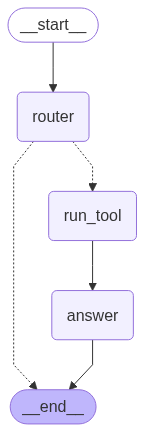

In [21]:
def call_llm(state: MessagesState):
    """Run LLM."""
    output = llm_with_tools.invoke(state["messages"])
    return {"messages": [output]}
    

def run_tool(state: MessagesState):
    """Perform the tool call."""
    result = []
    
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(
            {"role": "tool", "content": observation, "tool_call_id": tool_call["id"]}
        )
        
    return {"messages": result}


def should_continue(state: MessagesState) -> Literal["run_tool", "__end__"]:
    """Route to tool handler, or end if no tool calls are made."""
    # Get the last message
    messages = state["messages"]
    last_message = messages[-1]

    # If the last message is a tool call, check if it's a tool call
    if last_message.tool_calls:
        return "run_tool"
        
    # Otherwise, we stop (reply to the user)
    return END


workflow = StateGraph(MessagesState)
workflow.add_node("router", call_llm)
workflow.add_node("run_tool", run_tool)
workflow.add_node("answer", call_llm)
workflow.add_edge(START, "router")
workflow.add_conditional_edges(
    "router", should_continue, {"run_tool": "run_tool", END: END}
)
workflow.add_edge("run_tool", "answer")
workflow.add_edge("answer", END)


# Run the workflow
app = workflow.compile()
show_graph(app)

In [22]:
result = app.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Подготовь ответ моему начальнику (boss@company.ai) с подтверждением того, что я хочу посетить конференцию!",
            }
        ]
    }
)

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

Подготовь ответ моему начальнику (boss@company.ai) с подтверждением того, что я хочу посетить конференцию!
================================== Ai Message ==================================
Tool Calls:
  write_email (b0b848ca-99b9-47a3-a26e-44b280c3b93e)
 Call ID: b0b848ca-99b9-47a3-a26e-44b280c3b93e
  Args:
    content: Добрый день! Подтверждаю своё желание посетить конференцию. Буду рад получить от вас дальнейшие инструкции и детали. Спасибо!
    subject: Подтверждение участия в конференции
    to: boss@company.ai
================================= Tool Message =================================

Черновик письма создан

To: boss@company.ai

Subject: Подтверждение участия в конференции

Content:
Добрый день! Подтверждаю своё желание посетить конференцию. Буду рад получить от вас дальнейшие инструкции и детали. Спасибо!
================================== Ai Message ==================================
Tool Call

With these low level components, you can build many many different workflows and agents. See [this tutorial](https://langchain-ai.github.io/langgraph/tutorials/workflows/)!

Because agents are such a common pattern, [LangGraph](https://langchain-ai.github.io/langgraph/tutorials/workflows/#pre-built) has [a pre-built agent](https://langchain-ai.github.io/langgraph/agents/overview/) abstraction.

With LangGraph's [pre-built method](https://langchain-ai.github.io/langgraph/tutorials/workflows/#pre-built), we just pass in the LLM, tools, and prompt. 

In [23]:
from langgraph.prebuilt import create_react_agent

In [24]:
agent = create_react_agent(
    model=llm,
    tools=tools,
    prompt="Respond to the user's request using the tools provided.",
)

# Run the agent
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Подготовь ответ моему начальнику (boss@company.ai) с подтверждением того, что я хочу посетить конференцию!",
            }
        ]
    }
)

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

Подготовь ответ моему начальнику (boss@company.ai) с подтверждением того, что я хочу посетить конференцию!
================================== Ai Message ==================================
Tool Calls:
  write_email (ed882d2c-f360-42f9-a469-8d4ec178f62d)
 Call ID: ed882d2c-f360-42f9-a469-8d4ec178f62d
  Args:
    content: Я подтверждаю своё желание посетить конференцию. Буду рад возможности расширить свои знания и навыки, а также представить нашу компанию. Спасибо за поддержку и понимание.
    subject: Подтверждение участия в конференции
    to: boss@company.ai
================================= Tool Message =================================
Name: write_email

Черновик письма создан

To: boss@company.ai

Subject: Подтверждение участия в конференции

Content:
Я подтверждаю своё желание посетить конференцию. Буду рад возможности расширить свои знания и навыки, а также представить нашу компанию. Спасибо за подде

In the current implementation, conversation history is not saved

In [25]:
result = agent.invoke({"messages": [{"role": "user", "content": "Привет"}]})

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

Привет
================================== Ai Message ==================================

Здравствуйте! Как я могу вам помочь?


### Persistence

#### Threads

It can be very useful to allow agents to pause during long running tasks.

LangGraph has a built-in persistence layer, implemented through checkpointers, to enable this. 

When you compile graph with a checkpointer, the checkpointer saves a [checkpoint](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpoints) of the graph state at every step. 

Checkpoints are saved to a thread, which can be accessed after graph execution completes.

![checkpointer](img/checkpoints.png)

We compile the graph with a [checkpointer](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpointer-libraries).


In [26]:
from uuid import uuid4

from langgraph.checkpoint.memory import InMemorySaver

In [27]:
tools = [write_email, send_email]

agent = create_react_agent(
    model=llm,
    tools=tools,
    prompt="Respond to the user's request using the tools provided.",
    checkpointer=InMemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid4())}}
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Каких правил стоит придерживаться при написании электронных писем?",
            }
        ]
    },
    config
)

In [28]:
# Get the latest state snapshot
state = agent.get_state(config)

for message in state.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

Каких правил стоит придерживаться при написании электронных писем?
================================== Ai Message ==================================

При написании электронных писем важно следовать нескольким основным правилам:

1. **Четкость и лаконичность**: Излагайте свои мысли ясно и кратко. Не перегружайте письмо лишней информацией.
2. **Структура письма**: Используйте заголовки, абзацы и списки для улучшения читаемости текста.
3. **Корректное обращение**: Начинайте письмо с вежливого обращения (например, "Здравствуйте, Иван Иванович").
4. **Точность в теме письма**: Тема должна четко отражать содержание сообщения.
5. **Проверка орфографии и пунктуации**: Перед отправкой обязательно проверьте текст на наличие ошибок.
6. **Использование профессионального тона**: Письмо должно быть написано в деловом стиле, без использования жаргона или неформальных выражений.
7. **Подпись**: Включите подпись с указание

In [29]:
# Continue the conversation
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Отлично, давай используем правило 1, чтобы подготовить ответ моему начальнику с подтверждением того, что я хочу посетить конференцию.",
            }
        ]
    },
    config,
)

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

Каких правил стоит придерживаться при написании электронных писем?
================================== Ai Message ==================================

При написании электронных писем важно следовать нескольким основным правилам:

1. **Четкость и лаконичность**: Излагайте свои мысли ясно и кратко. Не перегружайте письмо лишней информацией.
2. **Структура письма**: Используйте заголовки, абзацы и списки для улучшения читаемости текста.
3. **Корректное обращение**: Начинайте письмо с вежливого обращения (например, "Здравствуйте, Иван Иванович").
4. **Точность в теме письма**: Тема должна четко отражать содержание сообщения.
5. **Проверка орфографии и пунктуации**: Перед отправкой обязательно проверьте текст на наличие ошибок.
6. **Использование профессионального тона**: Письмо должно быть написано в деловом стиле, без использования жаргона или неформальных выражений.
7. **Подпись**: Включите подпись с указание

In [30]:
# Continue the conversation
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Отлично! Давай отправим это письмо на boss@company.ai",
            }
        ]
    },
    config,
)

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

Каких правил стоит придерживаться при написании электронных писем?
================================== Ai Message ==================================

При написании электронных писем важно следовать нескольким основным правилам:

1. **Четкость и лаконичность**: Излагайте свои мысли ясно и кратко. Не перегружайте письмо лишней информацией.
2. **Структура письма**: Используйте заголовки, абзацы и списки для улучшения читаемости текста.
3. **Корректное обращение**: Начинайте письмо с вежливого обращения (например, "Здравствуйте, Иван Иванович").
4. **Точность в теме письма**: Тема должна четко отражать содержание сообщения.
5. **Проверка орфографии и пунктуации**: Перед отправкой обязательно проверьте текст на наличие ошибок.
6. **Использование профессионального тона**: Письмо должно быть написано в деловом стиле, без использования жаргона или неформальных выражений.
7. **Подпись**: Включите подпись с указание

#### Interrupts

In LangGraph, we can also use [interrupts](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/wait-user-input/) to stop graph execution at specific points.

Often this is used to collect input from a user and continue execution with collected input.

In [31]:
from uuid import uuid4

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from typing_extensions import TypedDict

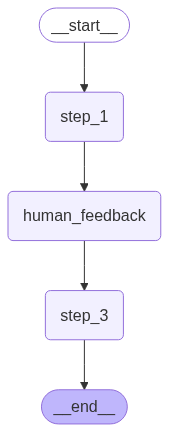

In [32]:
class State(TypedDict):
    input: str
    user_feedback: str


def step_1(state):
    print("---Step 1---")
    pass


def human_feedback(state):
    print("---human_feedback---")
    feedback = interrupt("Пожалуйста, предоставьте обратную связь:")
    return {"user_feedback": feedback}


def step_3(state):
    print("---Step 3---")
    pass


builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("human_feedback", human_feedback)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "human_feedback")
builder.add_edge("human_feedback", "step_3")
builder.add_edge("step_3", END)

# Set up memory
memory = InMemorySaver()

# Add
graph = builder.compile(checkpointer=memory)
show_graph(graph)

In [33]:
# Input
initial_input = {"input": "Привет!"}

# Thread
thread = {"configurable": {"thread_id": str(uuid4())}}

# Run the graph until the first interruption
for event in graph.stream(
    initial_input, thread, 
    stream_mode="updates"
):
    print(event, end="\n"*2)

---Step 1---
{'step_1': None}

---human_feedback---
{'__interrupt__': (Interrupt(value='Пожалуйста, предоставьте обратную связь:', resumable=True, ns=['human_feedback:635b54f3-adad-edb3-2bbc-83b945318fd4']),)}



To resume from an interrupt, we can use [the `Command` object](https://langchain-ai.github.io/langgraph/how-tos/command/). 

We'll use it to resume the graph from the interrupted state, passing the value to return from the interrupt call to `resume`. 

In [34]:
# Continue the graph execution
for event in graph.stream(
    Command(resume="Перейди на шаг 3!"),
    thread,
    stream_mode="updates",
):
    print(event, end="\n"*2)

---human_feedback---
{'human_feedback': {'user_feedback': 'Перейди на шаг 3!'}}

---Step 3---
{'step_3': None}



### Tracing

When we are using LangChain or LangGraph, LangSmith logging [will work out of the box](https://docs.smith.langchain.com/observability/how_to_guides/trace_with_langgraph) with the following environment variables set:

```
export LANGSMITH_TRACING=true
export LANGSMITH_API_KEY="<your-langsmith-api-key>"
```

### Использование Langfuse для трейсинга

Помимо LangSmith, вы можете использовать Langfuse для логирования и мониторинга. Для этого необходимо добавить callback handler при вызове агента.

In [ ]:
# Пример использования агента с Langfuse логированием
agent_with_langfuse = create_react_agent(
    model=llm,
    tools=tools,
    prompt="Respond to the user's request using the tools provided.",
)

# Запуск агента с Langfuse callback
result = agent_with_langfuse.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Подготовь короткое письмо моему коллеге (colleague@company.ai) о завтрашнем митинге.",
            }
        ]
    },
    config={"callbacks": [langfuse_handler]}
)

for message in result["messages"]:
    message.pretty_print()
    
# Дождитесь завершения отправки логов в Langfuse
langfuse_handler.langfuse.flush()

После выполнения вы можете увидеть трейсы в дашборде Langfuse, включая:
- Все вызовы LLM с промптами и ответами
- Использование токенов и стоимость
- Вызовы инструментов
- Время выполнения каждого шага

Для настройки необходимо добавить в `.env` файл:
```
LANGFUSE_PUBLIC_KEY=your_public_key
LANGFUSE_SECRET_KEY=your_secret_key
LANGFUSE_HOST=http://localhost:3000  # локальная версия Langfuse
```

Дашборд будет доступен по адресу: http://localhost:3000

### Deployment

We can also deploy our graph using [LangGraph Platform](https://langchain-ai.github.io/langgraph/concepts/langgraph_platform/). 

This creates a server [with an API](https://langchain-ai.github.io/langgraph/cloud/reference/api/api_ref.html) that we can use to interact with our graph and an interactive IDE, LangGraph [Studio](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/).

We simply need to ensure our project has [a structure](https://langchain-ai.github.io/langgraph/concepts/application_structure/) like this:

```
my-app/
├── src/email_assistant # all project code lies within here
│   └── langgraph101.py # code for constructing your graph
├── .env # environment variables
├── langgraph.json  # configuration file for LangGraph
└── pyproject.toml # dependencies for your project
```

The `langgraph.json` file specifies the dependencies, graphs, environment variables, and other settings required to start a LangGraph server.

To test this, let's deploy `langgraph_101.py`. We have it in our `langgraph.json` file in this repo:

```
 "langgraph101": "./src/email_assistant/langgraph_101.py:app",
```

For LangGraph Platform, there are a range of [deployment options](https://langchain-ai.github.io/langgraph/tutorials/deployment/): 
 
* Local deployments can be started with `langgraph dev` from the root directory of the repo. Checkpoints are saved to the local filesystem.
* There are also various [self-hosted options](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options). 
* For hosted deployments, checkpoints are saved to Postgres using a postgres [checkpointer](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpointer-libraries). 

Test: 
```
Подготовь ответ моему начальнику (boss@company.ai) с подтверждением того, что я хочу посетить конференцию!

Отправь данное письмо
```

Here we can see a visualization of the graph as well as the graph state in Studio.

![langgraph_studio](img/langgraph_studio.png)
![langgraph_studio](img/langgraph_studio_chat.png)

Also, you can see API docs for the local deployment here:

http://127.0.0.1:2024/docs